 Building Model: ResNet50 | CBAM=True
✅ CAMAD model loaded
Evaluating Model...

Classification Report
              precision    recall  f1-score   support

       akiec     0.5821    0.7647    0.6610        51
         bcc     0.7568    0.7273    0.7417        77
         bkl     0.6712    0.6242    0.6469       157
          df     0.8333    0.4545    0.5882        22
         mel     0.6575    0.5714    0.6115       168
          nv     0.8944    0.9230    0.9085      1000
        vasc     0.9000    0.8182    0.8571        22

    accuracy                         0.8283      1497
   macro avg     0.7565    0.6976    0.7164      1497
weighted avg     0.8259    0.8283    0.8252      1497

Balanced Accuracy: 0.6976
Melanoma Recall:   0.5714

 Saved Confusion Matrix to /Users/mati/adv_skin_cancer/reports/figures/confusion_matrix_final.png


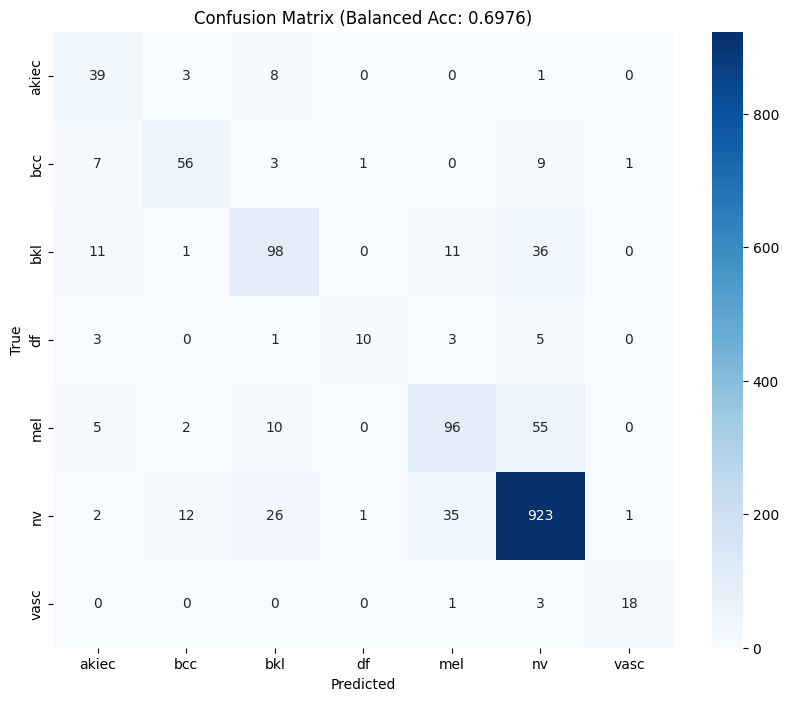

ROC AUC: 0.9197

🎯 Optimal Clinical Threshold: 0.2
threshold        0.200000
mel_recall       0.863095
specificity      0.803612
FN              23.000000
FP             261.000000
Name: 19, dtype: float64

📊 Performance at Clinical Threshold
Melanoma Recall: 0.8631
Specificity: 0.8036
False Negatives (missed melanoma): 23
95% CI for Melanoma Recall: [0.8068, 0.9131]


In [6]:
import os
import sys
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix
from torchvision import models as torchvision_models

sys.path.append('..')

from src.config import config
from src.models import get_model
from src.dataset import HAM10000Dataset
from src.transforms import get_transforms
from src.eval import evaluate_model_performance

# =======================
# Basic Setup
# =======================
device = config.DEVICE
MEL_IDX = 4   # melanoma class index

# =======================
# Load Test Data
# =======================
test_trans = get_transforms(split='test')
test_ds = HAM10000Dataset(config.PROCESSED_DATA_DIR / "test.csv", transform=test_trans)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=config.BATCH_SIZE, shuffle=False)

# =======================
# Load CAMAD Model Only (ตัวเดียวพอสำหรับ threshold analysis)
# =======================
config.BASE_MODEL = 'resnet50'
config.USE_CBAM = True

model = get_model().to(device)
ckpt = torch.load(config.CHECKPOINT_DIR / "best_model_resnet50_cbam.pth", map_location=device)
state_dict = ckpt['model_state_dict'] if 'model_state_dict' in ckpt else ckpt
model.load_state_dict(state_dict, strict=False)
model.eval()

print("✅ CAMAD model loaded")

# =======================
# Get Predictions
# =======================
y_true, _, y_prob = evaluate_model_performance(model, test_loader, device)
y_true = np.array(y_true)
y_prob = np.array(y_prob)

y_true_bin = (y_true == MEL_IDX).astype(int)
y_score = y_prob[:, MEL_IDX]

# =======================
# ROC Curve (for reporting only)
# =======================
fpr, tpr, roc_thresh = roc_curve(y_true_bin, y_score)
roc_auc = auc(fpr, tpr)
print(f"ROC AUC: {roc_auc:.4f}")

# =======================
# Clinical Threshold Optimization (GRID SEARCH)
# Goal: Max melanoma recall with benign precision ≥ 0.80
# =======================
thresholds = np.arange(0.01, 1.00, 0.01)
records = []

for t in thresholds:
    y_pred = (y_score >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true_bin, y_pred).ravel()

    melanoma_recall = tp / (tp + fn)          # Sensitivity
    specificity = tn / (tn + fp)              # True Negative Rate

    records.append([t, melanoma_recall, specificity, fn, fp])

df_thresh = pd.DataFrame(records, columns=[
    "threshold", "mel_recall", "specificity", "FN", "FP"
])

# Clinical constraint: Specificity ≥ 0.80
df_valid = df_thresh[df_thresh["specificity"] >= 0.80]

best_row = df_valid.sort_values("mel_recall", ascending=False).iloc[0]
best_t = best_row["threshold"]

print("\n🎯 Optimal Clinical Threshold:", round(best_t, 2))
print(best_row)


# =======================
# Metrics at Best Threshold
# =======================
y_pred_best = (y_score >= best_t).astype(int)
tn, fp, fn, tp = confusion_matrix(y_true_bin, y_pred_best).ravel()

print("\n📊 Performance at Clinical Threshold")
print(f"Melanoma Recall: {tp/(tp+fn):.4f}")
print(f"Specificity: {tn/(tn+fp):.4f}")
print(f"False Negatives (missed melanoma): {fn}")

# =======================
# Bootstrap 95% CI for Melanoma Recall
# =======================
from sklearn.utils import resample

boot_recalls = []
for _ in range(1000):
    idx = resample(range(len(y_true_bin)))
    yt = y_true_bin[idx]
    ys = y_score[idx]
    yp = (ys >= best_t).astype(int)
    tn, fp, fn, tp = confusion_matrix(yt, yp).ravel()
    if (tp + fn) > 0:
        boot_recalls.append(tp / (tp + fn))

ci_low, ci_high = np.percentile(boot_recalls, [2.5, 97.5])
print(f"95% CI for Melanoma Recall: [{ci_low:.4f}, {ci_high:.4f}]")


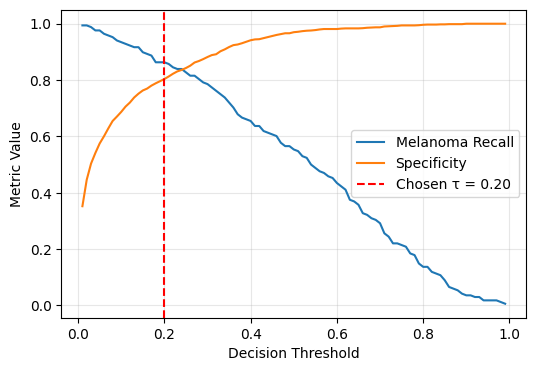

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(df_thresh["threshold"], df_thresh["mel_recall"], label="Melanoma Recall")
plt.plot(df_thresh["threshold"], df_thresh["specificity"], label="Specificity")
plt.axvline(best_t, color='red', linestyle='--', label=f'Chosen τ = {best_t:.2f}')
plt.xlabel("Decision Threshold")
plt.ylabel("Metric Value")
#plt.title("Clinical Threshold Optimization")
plt.legend()
plt.grid(alpha=0.3)
save_path = config.FIGURE_DIR / "Clinical_Threshold_Opt"
plt.savefig(save_path,dpi=200, bbox_inches='tight')
plt.show()



In [3]:
import sys, torch, numpy as np, pandas as pd
sys.path.append('..')
 
from sklearn.metrics import confusion_matrix
from src.config import config
from src.models import get_model
from src.dataset import HAM10000Dataset
from src.transforms import get_transforms
from src.eval import evaluate_model_performance

MEL_IDX = config.CLASS_TO_IDX['mel']
SPEC_FLOOR = 0.80
 
# ---------- 1) โหลด CAMAD checkpoint เดิม ----------
config.SELECTED_EXP = 'resnet50_cbam'
config.__init__()
model = get_model().to(config.DEVICE)
ckpt = torch.load(config.CHECKPOINT_DIR / "best_model_resnet50_cbam.pth",
                  map_location=config.DEVICE)
model.load_state_dict(ckpt.get('model_state_dict', ckpt), strict=False)
model.eval()
 
 
def probs_for(split_csv):
    """คืน (y_true, y_prob) ของ split ที่ระบุ"""
    ds = HAM10000Dataset(config.PROCESSED_DATA_DIR / split_csv,
                         transform=get_transforms('val'))
    loader = torch.utils.data.DataLoader(ds, batch_size=config.BATCH_SIZE,
                                         shuffle=False)
    y_true, _, y_prob = evaluate_model_performance(model, loader, config.DEVICE)
    return np.array(y_true), np.array(y_prob)
 
 
def grid_search(y_true, y_prob, label):
    """วน tau แบบเดียวกับเดิม แต่รับ split เป็น argument"""
    y_bin = (y_true == MEL_IDX).astype(int)
    y_score = y_prob[:, MEL_IDX]
 
    rows = []
    for t in np.arange(0.01, 1.00, 0.01):
        tn, fp, fn, tp = confusion_matrix(y_bin, (y_score >= t).astype(int)).ravel()
        rows.append([round(t, 2), tp / (tp + fn), tn / (tn + fp), fn, fp])
 
    df = pd.DataFrame(rows, columns=['tau', 'mel_recall', 'specificity', 'FN', 'FP'])
    ok = df[df['specificity'] >= SPEC_FLOOR]
    best = ok.sort_values('mel_recall', ascending=False).iloc[0]
 
    print(f"\n=== {label} (n={len(y_true)}, MEL={y_bin.sum()}) ===")
    print(f"tau* = {best['tau']:.2f} | recall = {best['mel_recall']:.4f} "
          f"| specificity = {best['specificity']:.4f}")
    # ดูค่ารอบ ๆ เพื่อเช็คว่า tau ไวต่อ noise แค่ไหน
    print(df[(df['tau'] >= best['tau'] - 0.04) & (df['tau'] <= best['tau'] + 0.04)]
          .to_string(index=False))
    return df, float(best['tau'])

✓ SkinCancerClassification v1.0.0
Note: Other modules will be loaded as they are created
 Building Model: ResNet50 | CBAM=True


Evaluating Model...

Classification Report
              precision    recall  f1-score   support

       akiec     0.6410    0.5814    0.6098        43
         bcc     0.6951    0.7917    0.7403        72
         bkl     0.7566    0.6886    0.7210       167
          df     1.0000    0.4706    0.6400        17
         mel     0.6383    0.5357    0.5825       168
          nv     0.8990    0.9405    0.9193       975
        vasc     0.7273    0.7273    0.7273        22

    accuracy                         0.8388      1464
   macro avg     0.7653    0.6765    0.7057      1464
weighted avg     0.8338    0.8388    0.8340      1464

Balanced Accuracy: 0.6765
Melanoma Recall:   0.5357

 Saved Confusion Matrix to /Users/mati/adv_skin_cancer/reports/figures/confusion_matrix_final.png


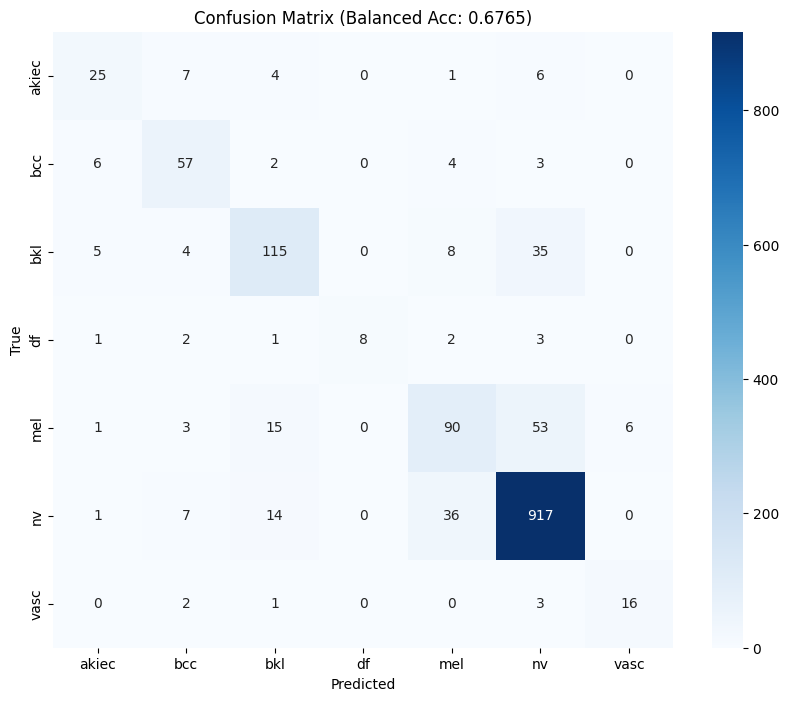


=== VALIDATION (สำหรับเลือก tau) (n=1464, MEL=168) ===
tau* = 0.17 | recall = 0.8810 | specificity = 0.8002
 tau  mel_recall  specificity  FN  FP
0.13    0.904762     0.750000  16 324
0.14    0.898810     0.763117  17 307
0.15    0.886905     0.779321  19 286
0.16    0.880952     0.790123  20 272
0.17    0.880952     0.800154  20 259
0.18    0.869048     0.811728  22 244
0.19    0.863095     0.817901  23 236
0.20    0.857143     0.821759  24 231
0.21    0.857143     0.834105  24 215


In [4]:
y_val, p_val = probs_for('val.csv')
df_val, tau_val = grid_search(y_val, p_val, 'VALIDATION (สำหรับเลือก tau)')

Evaluating Model...

Classification Report
              precision    recall  f1-score   support

       akiec     0.5821    0.7647    0.6610        51
         bcc     0.7568    0.7273    0.7417        77
         bkl     0.6712    0.6242    0.6469       157
          df     0.8333    0.4545    0.5882        22
         mel     0.6575    0.5714    0.6115       168
          nv     0.8944    0.9230    0.9085      1000
        vasc     0.9000    0.8182    0.8571        22

    accuracy                         0.8283      1497
   macro avg     0.7565    0.6976    0.7164      1497
weighted avg     0.8259    0.8283    0.8252      1497

Balanced Accuracy: 0.6976
Melanoma Recall:   0.5714

 Saved Confusion Matrix to /Users/mati/adv_skin_cancer/reports/figures/confusion_matrix_final.png


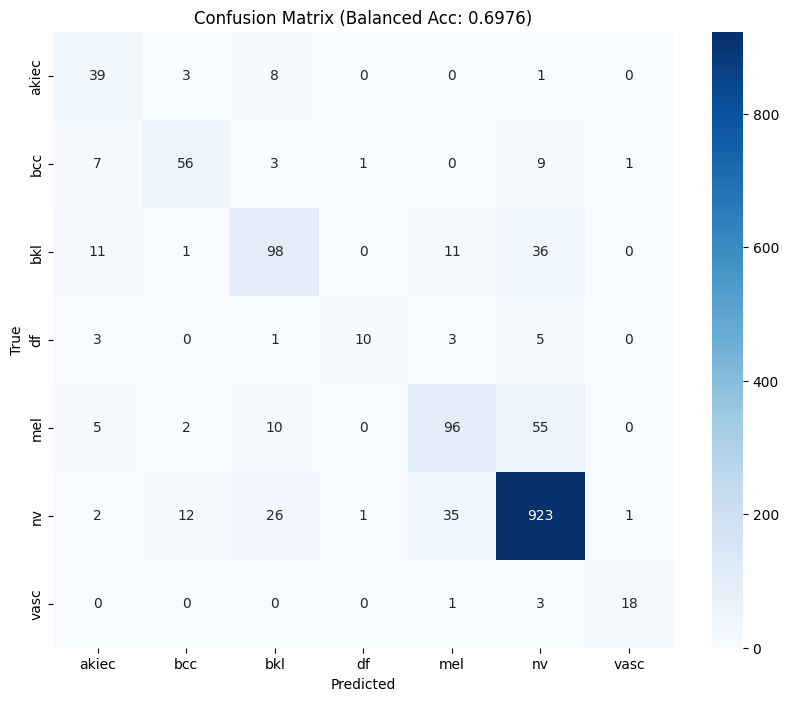


=== TEST @ tau = 0.17 (held-out) ===
Melanoma recall : 0.8869  (149/168)
Specificity     : 0.7803
Melanoma prec.  : 0.3379


In [5]:
y_test, p_test = probs_for('test.csv')
y_bin_t = (y_test == MEL_IDX).astype(int)
tn, fp, fn, tp = confusion_matrix(
    y_bin_t, (p_test[:, MEL_IDX] >= tau_val).astype(int)).ravel()
 
print(f"\n=== TEST @ tau = {tau_val:.2f} (held-out) ===")
print(f"Melanoma recall : {tp/(tp+fn):.4f}  ({tp}/{tp+fn})")
print(f"Specificity     : {tn/(tn+fp):.4f}")
print(f"Melanoma prec.  : {tp/(tp+fp):.4f}")

In [6]:
df_test, tau_test = grid_search(y_test, p_test, 'TEST (วิธีเดิม - optimistic)')
print(f"\n>>> tau(val) = {tau_val:.2f}   vs   tau(test) = {tau_test:.2f}")


=== TEST (วิธีเดิม - optimistic) (n=1497, MEL=168) ===
tau* = 0.20 | recall = 0.8631 | specificity = 0.8036
 tau  mel_recall  specificity  FN  FP
0.16    0.892857     0.769752  18 306
0.17    0.886905     0.780286  19 292
0.18    0.863095     0.788563  23 281
0.19    0.863095     0.796087  23 271
0.20    0.863095     0.803612  23 261
0.21    0.857143     0.812641  24 249
0.22    0.845238     0.822423  26 236
0.23    0.839286     0.830700  27 225
0.24    0.839286     0.835967  27 218

>>> tau(val) = 0.17   vs   tau(test) = 0.20
